# 06. A7 신상품 마스터와 POS NPD 데이터 중복 분석

**목적**: POS 데이터에서 추출한 분석 대상 NPD 상품들과 A7 신상품 정보 데이터 간의 중복도를 파악하고 일치하는 상품코드 개수와 샘플을 점검합니다.

In [27]:
import pandas as pd
import polars as pl
import os
import re
from pathlib import Path

BASE_DIR = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
B4_FILTERED_PATH = BASE_DIR / 'data' / 'processed' / 'B4_ITEM_DV_INFO_filtered.parquet'
A7_RAW_PATH = BASE_DIR / 'data' / 'raw' / 'A7_NP_ITEM_INFO.csv'

print('BASE_DIR:', BASE_DIR)
print('B4 Filtered exists:', B4_FILTERED_PATH.exists())
print('A7 Raw exists:', A7_RAW_PATH.exists())

# 상품명 정규화 함수
def normalize_item_name(name):
    if not isinstance(name, str):
        return ""
    name = name.lower()
    name = re.sub(r'^[^)]+\)', '', name)  # 괄호 접두사 제거
    name = re.sub(r'[★☆■◆▲▼●○◈◇♡♥♣♠]', '', name)  # 특수문자 제거
    name = re.sub(r'\d+\s*(?:g|입|ml|p|입수)\b', '', name)  # 용량 단위 제거
    name = re.sub(r'\d+\s*(?:g|입|ml|p|입수)\(.*?\)', '', name)
    name = re.sub(r'\(.*?\)', '', name)  # 괄호 내용 제거
    name = re.sub(r'[^a-zA-Z0-9가-힣]', '', name)  # 나머지 특수문자/공백 제거
    return name.strip()

# 엑셀 정규화명 클리닝 함수 (공백 및 특수문자만 제거)
def simple_clean(name):
    if not isinstance(name, str):
        return ""
    name = name.lower()
    return re.sub(r'[^a-zA-Z0-9가-힣]', '', name).strip()


BASE_DIR: c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework
B4 Filtered exists: True
A7 Raw exists: True


## 1. 데이터 로드 및 타입 변환

In [28]:
# POS NPD 데이터 로드
df_b4 = pd.read_parquet(B4_FILTERED_PATH)
df_npd = df_b4[df_b4['is_npd'] == True].copy()
print(f'POS NPD 원본 상품 수 (is_npd == True): {len(df_npd):,}개')

# A7 데이터 로드
df_a7 = pd.read_csv(A7_RAW_PATH, dtype={'ITEM_CD': str})
print(f'A7 신상품 마스터 원본 상품 수: {len(df_a7):,}개')

# 1. 정규화명 미리 생성
df_npd['norm_nm'] = df_npd['ITEM_NM'].apply(normalize_item_name)
df_a7['norm_nm'] = df_a7['ITEM_NM'].apply(normalize_item_name)

# 2. product_name_review_final.xlsx 로드 및 제외 대상 필터링
excel_path = BASE_DIR / 'data' / 'processed' / 'product_name_review_final.xlsx'
if excel_path.exists():
    df_excel = pd.read_excel(excel_path)
    df_excel['수정명_str'] = df_excel['수정명'].astype(str).str.strip()
    df_exclude = df_excel[df_excel['수정명_str'] == 'O'].copy()
    
    # 엑셀 원본명을 정규화한 텍스트와 엑셀 정규화명을 심플 클리닝한 텍스트의 합집합
    exclude_orig = set(df_exclude['원본명'].apply(normalize_item_name).dropna().unique())
    exclude_norm = set(df_exclude['정규화명'].apply(simple_clean).dropna().unique())
    exclude_set = exclude_orig.union(exclude_norm)
    exclude_set.discard('')
    
    print(f'[필터링] 분석 제외 대상 고유 정규화명 수: {len(exclude_set)}개')
    
    npd_before = len(df_npd)
    a7_before = len(df_a7)
    
    df_npd = df_npd[~df_npd['norm_nm'].isin(exclude_set)].copy()
    df_a7 = df_a7[~df_a7['norm_nm'].isin(exclude_set)].copy()
    
    print(f'[필터링] POS NPD 분석 대상 상품 수: {npd_before:,}개 -> {len(df_npd):,}개 (제거: {npd_before - len(df_npd):,}개)')
    print(f'[필터링] A7 분석 대상 상품 수: {a7_before:,}개 -> {len(df_a7):,}개 (제거: {a7_before - len(df_a7):,}개)')
else:
    print('[필터링] product_name_review_final.xlsx 파일을 찾을 수 없어 필터링을 건너뜁니다.')


POS NPD 원본 상품 수 (is_npd == True): 2,493개
A7 신상품 마스터 원본 상품 수: 1,179개
[필터링] 분석 제외 대상 고유 정규화명 수: 334개
[필터링] POS NPD 분석 대상 상품 수: 2,493개 -> 2,321개 (제거: 172개)
[필터링] A7 분석 대상 상품 수: 1,179개 -> 1,068개 (제거: 111개)


## 2. 상품코드 정규화

In [29]:
# 공백 제거 및 문자열 형식 통일
df_npd['ITEM_CD'] = df_npd['ITEM_CD'].astype(str).str.strip()
df_a7['ITEM_CD'] = df_a7['ITEM_CD'].astype(str).str.strip()

# 고유 상품코드 추출
npd_cds = set(df_npd['ITEM_CD'])
a7_cds = set(df_a7['ITEM_CD'])

print(f'POS NPD 고유 상품코드 수: {len(npd_cds):,}개')
print(f'A7 고유 상품코드 수: {len(a7_cds):,}개')


POS NPD 고유 상품코드 수: 2,321개
A7 고유 상품코드 수: 1,029개


## 3. 중복도(Overlap) 분석

In [30]:
overlap_cds = npd_cds.intersection(a7_cds)
overlap_count = len(overlap_cds)

print(f'중복(교집합) 상품코드 수: {overlap_count:,}개')
print(f'POS NPD 중 A7에 매핑되는 비율: {overlap_count / len(npd_cds) * 100:.2f}% ({overlap_count}/{len(npd_cds)})')
print(f'A7 상품 중 POS NPD에 매핑되는 비율: {overlap_count / len(a7_cds) * 100:.2f}% ({overlap_count}/{len(a7_cds)})')


중복(교집합) 상품코드 수: 513개
POS NPD 중 A7에 매핑되는 비율: 22.10% (513/2321)
A7 상품 중 POS NPD에 매핑되는 비율: 49.85% (513/1029)


## 4. 겹치는 상품 상세 목록 샘플 확인

In [31]:
df_overlap = df_npd[df_npd['ITEM_CD'].isin(overlap_cds)].copy()
df_overlap_sample = df_overlap[['ITEM_CD', 'ITEM_NM', 'ITEM_LRDV_NM', 'ITEM_MDDV_NM', 'ITEM_SMDV_NM']]

print('--- 겹치는 상품 상위 30개 샘플 ---')
print(df_overlap_sample.head(30).to_string(index=False))


--- 겹치는 상품 상위 30개 샘플 ---
ITEM_CD             ITEM_NM ITEM_LRDV_NM ITEM_MDDV_NM ITEM_SMDV_NM
 117583         롯데)야채크래커83g           과자         비스킷류          크래커
 115456        천하)골든씨씨쉘250g           과자          초콜릿         행사상품
 600024        롯데)씨리얼초코컵89g           과자         비스킷류          크래커
 600640  TDF)아미카엘도라다감자칩400g           과자          스낵류         감자스낵
 600876 오리온)초코파이딸기408g(봄한정)           과자         비스킷류           파이
 601101       오리온)멜론후레쉬베리8입           과자         비스킷류           파이
 114056  크라운)카라멜콘메이플(대)154g           과자          스낵류       알뜰절약상품
 117876        삼경)로아커말차110g           과자         비스킷류          크래커
 601461  롯데)길리안템테이션오리지널(4입)           과자          초콜릿         행사상품
 117565     롯데)드림카카오82% 86g           과자          초콜릿         볼초콜릿
 112177        동서)오레오딸기100g           과자         비스킷류           쿠키
 113212         오리온)초코파이18입           과자         비스킷류           파이
 601465       농심)린도볼밀크(12입)           과자          초콜릿         행사상품
 601467     농심)린도볼어쏘티드(12입)          

## 5. 겹치는 상품의 중분류(ITEM_MDDV_NM) 분포 시각화

중복된 상품 580개에 대해 중분류 기준으로 어떠한 상품들이 분포하고 있는지 파이차트(도넛차트)로 확인합니다.

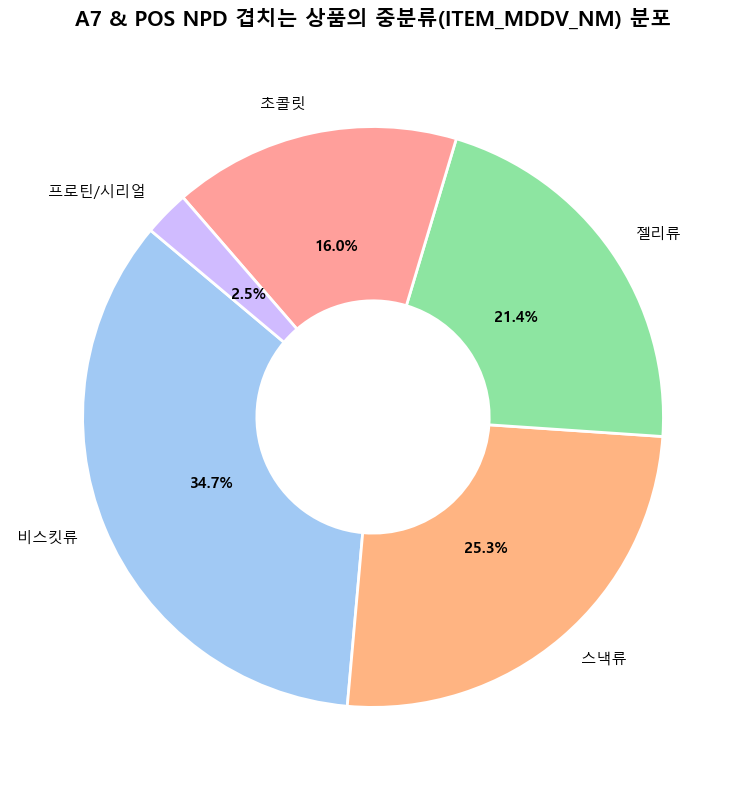

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 중분류 빈도 계산
mddv_counts = df_overlap['ITEM_MDDV_NM'].value_counts()

# 도넛 차트 시각화
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    mddv_counts, 
    labels=mddv_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel', len(mddv_counts)),
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2)
)

plt.setp(autotexts, size=11, weight='bold')
plt.setp(texts, size=11)
ax.set_title('A7 & POS NPD 겹치는 상품의 중분류(ITEM_MDDV_NM) 분포', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 6. 데이터 비교 분석용 파일 내보내기

POS NPD 데이터와 A7 신상품 데이터의 원본명 및 정규화명을 직접 엑셀 등에서 비교·검토할 수 있도록 `| 데이터 소스 | 상품코드 | 원본명 | 정규화명 | 정규화명_매칭여부 |` 형태로 가공하여 CSV 파일로 저장합니다.

In [33]:
# 교집합 정규화명 구하기
npd_names = set(df_npd[df_npd['norm_nm'] != '']['norm_nm'])
a7_names = set(df_a7[df_a7['norm_nm'] != '']['norm_nm'])
name_overlap = npd_names.intersection(a7_names)

# POS subset
df_pos_sub = df_npd[['ITEM_CD', 'ITEM_NM', 'norm_nm', 'ITEM_MDDV_NM']].copy()
df_pos_sub = df_pos_sub.rename(columns={'ITEM_MDDV_NM': '중분류명'})
df_pos_sub['데이터 소스'] = 'POS_NPD'

# A7 subset
df_a7_sub = df_a7[['ITEM_CD', 'ITEM_NM', 'norm_nm', 'ITEM_MDDV_CD']].copy()
code_to_name_map = {1101: '비스킷류', 1102: '스낵류', 1103: '캔디류', 1104: '초콜릿', 1105: '껌', 1106: '프로틴/시리얼', 1107: '젤리류'}
a7_mddv_cds = pd.to_numeric(df_a7_sub['ITEM_MDDV_CD'], errors='coerce').fillna(0).astype(int)
df_a7_sub['중분류명'] = a7_mddv_cds.map(code_to_name_map).fillna('기타/기획')
df_a7_sub = df_a7_sub.drop(columns=['ITEM_MDDV_CD'])
df_a7_sub['데이터 소스'] = 'A7_NP_ITEM_INFO'

# Concat
df_comp = pd.concat([df_pos_sub, df_a7_sub], ignore_index=True)
df_comp = df_comp.rename(columns={'ITEM_CD': '상품코드', 'ITEM_NM': '원본명', 'norm_nm': '정규화명'})

# Add matching status Y/N
df_comp['정규화명_매칭여부'] = df_comp['정규화명'].apply(lambda x: 'Y' if x in name_overlap and x != "" else 'N')
df_comp = df_comp[['데이터 소스', '상품코드', '중분류명', '원본명', '정규화명', '정규화명_매칭여부']]
df_comp = df_comp.drop_duplicates().reset_index(drop=True)

# Export
output_path = BASE_DIR / 'data' / 'processed' / 'a7_pos_name_comparison.csv'
df_comp.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'Comparison CSV saved at: data/processed/a7_pos_name_comparison.csv')
print(f'Total unique rows: {len(df_comp):,}')
print(f'Matched Y count: {len(df_comp[df_comp["정규화명_매칭여부"] == "Y"]):,}')


Comparison CSV saved at: data/processed/a7_pos_name_comparison.csv
Total unique rows: 3,353
Matched Y count: 1,052


## 7. 분석 대상 46대 타겟 중분류 기준 교집합 재계산 및 분류 불일치 분석

1. **대상 카테고리 필터링**: 파레토 필터(Pareto Filter) 기준에 따라 사용여부가 `O`로 마킹되어 HIN 프레임워크 최종 분석 대상에 올라온 **46개 중분류**를 기준으로 데이터를 정렬합니다.
2. **교집합 재산출 및 대조**: POS NPD 대상 상품(이미 46개 중분류 필터링 완료 상태)과 A7 기획 등록 데이터의 교집합 및 분류 체계 불일치 상품 리스트(`data/processed/a7_pos_category_mismatches.csv`)를 재추출합니다.
3.  제과/간식류(과자군) 카테고리 상품만 수집되어 있는 데이터셋 POS와는 ** 비스킷류, 스낵류, 젤리류, 초콜릿, 프로틴/시리얼 5개만 겹침

In [34]:
import os
import re

# 1. Pareto 필터 로드 (실제 타겟 중분류 46개 추출)
eda_dir = BASE_DIR / 'eda'
f_name = [f for f in os.listdir(eda_dir) if 'pareto' in f][0]
df_pareto = pd.read_excel(eda_dir / f_name)
target_mddvs = set(df_pareto[df_pareto['사용여부'] == 'O']['ITEM_MDDV_NM'].unique())

# 2. POS 측 46대 중분류 필터링
df_npd_tgt = df_npd[df_npd['ITEM_MDDV_NM'].isin(target_mddvs)].copy()

# A7 측 타겟 필터링
code_to_name_map = {1101: '비스킷류', 1102: '스낵류', 1103: '캔디류', 1104: '초콜릿', 1105: '껌', 1106: '프로틴/시리얼', 1107: '젤리류'}
df_a7['A7_MDDV_NM_est'] = df_a7['ITEM_MDDV_CD'].map(code_to_name_map).fillna('기타/기획')
df_a7_tgt = df_a7[df_a7['A7_MDDV_NM_est'].isin(target_mddvs) | (df_a7['A7_MDDV_NM_est'] == '기타/기획')].copy()

# 고유 키 추출
npd_cds_tgt = set(df_npd_tgt['ITEM_CD'].astype(str).str.strip())
a7_cds_tgt = set(df_a7_tgt['ITEM_CD'].astype(str).str.strip())
npd_nms_tgt = set(df_npd_tgt[df_npd_tgt['norm_nm'] != '']['norm_nm'])
a7_nms_tgt = set(df_a7_tgt[df_a7_tgt['norm_nm'] != '']['norm_nm'])

# 교집합
code_ol_tgt = npd_cds_tgt.intersection(a7_cds_tgt)
name_ol_tgt = npd_nms_tgt.intersection(a7_nms_tgt)

print('--- 46대 타겟 중분류 기준 교집합 ---')
print(f'POS NPD 타겟 상품 수: {len(df_npd_tgt):,}개')
print(f'A7 타겟 상품 수: {len(df_a7_tgt):,}개')
print(f'코드 기준 교집합 수: {len(code_ol_tgt):,}개')
print(f'정규화명 기준 교집합 수: {len(name_ol_tgt):,}개')

# 3. 분류 체계 불일치 분석
df_ol_info = pd.merge(
    df_npd[['ITEM_CD', 'ITEM_NM', 'ITEM_MDDV_NM']],
    df_a7[['ITEM_CD', 'ITEM_NM', 'ITEM_MDDV_CD']].rename(columns={'ITEM_NM': 'A7_ITEM_NM'}),
    on='ITEM_CD'
)
df_ol_info['A7_MDDV_NM'] = df_ol_info['ITEM_MDDV_CD'].map(code_to_name_map).fillna('기타/기획')

def check_mismatch(row):
    p, a = row['ITEM_MDDV_NM'], row['A7_MDDV_NM']
    if p == a: return False
    if p == '젤리' and a == '젤리류': return False
    return True

df_ol_info['mismatch'] = df_ol_info.apply(check_mismatch, axis=1)
df_mismatched = df_ol_info[df_ol_info['mismatch'] == True].copy()

print('\n--- 분류 체계 불일치 분석 ---')
print(f'코드 매칭 상품 중 분류 불일치 상품 수: {len(df_mismatched):,}개')

# 내보내기
mismatched_export = df_mismatched[['ITEM_CD', 'ITEM_NM', 'ITEM_MDDV_NM', 'A7_ITEM_NM', 'ITEM_MDDV_CD', 'A7_MDDV_NM']].rename(columns={
    'ITEM_CD': '상품코드', 'ITEM_NM': 'POS_상품명', 'ITEM_MDDV_NM': 'POS_중분류명',
    'A7_ITEM_NM': 'A7_상품명', 'ITEM_MDDV_CD': 'A7_중분류코드', 'A7_MDDV_NM': 'A7_중분류명_추정'
})
mismatched_export = mismatched_export.drop_duplicates().reset_index(drop=True)
mismatched_export.to_csv(BASE_DIR / 'data' / 'processed' / 'a7_pos_category_mismatches.csv', index=False, encoding='utf-8-sig')
print(f'불일치 상품 리스트 저장 완료: data/processed/a7_pos_category_mismatches.csv')


--- 46대 타겟 중분류 기준 교집합 ---
POS NPD 타겟 상품 수: 2,321개
A7 타겟 상품 수: 872개
코드 기준 교집합 수: 511개
정규화명 기준 교집합 수: 484개

--- 분류 체계 불일치 분석 ---
코드 매칭 상품 중 분류 불일치 상품 수: 14개
불일치 상품 리스트 저장 완료: data/processed/a7_pos_category_mismatches.csv
